In [ ]:
import glob
import warnings
import joblib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from sklearn.linear_model import BayesianRidge
from sklearn.linear_model import ElasticNetCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
import os
warnings.filterwarnings("ignore")
from adjustText import adjust_text

# Path to data files
DATA_DIR = "../data"

#Path to images
IMG_DIR = "../images"

#Path to models
MODEL_PATH = "../models/lineup_model.pkl"

# Minimum minute share to be included in rotation
MIN_PCT_THRESHOLD = 15.0

# Roles considered "frontcourt" for spacing features
FRONTCOURT_ROLES = {"Stretch 4", "PF/C", "C"}
GUARD_ROLES      = {"Pure PG", "Scoring PG", "Combo G"}
WING_ROLES       = {"Wing G", "Wing F"}

ALL_ROLES = ["Pure PG", "Scoring PG", "Combo G", "Wing G", "Wing F",
             "Stretch 4", "PF/C", "C"]

# High-value role pairs from MIT Sloan paper philosophy
SYNERGY_PAIRS = [
    ("Pure PG",    "Stretch 4"),
    ("Pure PG",    "PF/C"),
    ("Scoring PG", "Stretch 4"),
    ("Combo G",    "Stretch 4"),
    ("Combo G",    "PF/C"),
    ("Wing F",     "Pure PG"),
]


In [2]:
def load_all_seasons(data_dir: str):
    player_files = sorted(glob.glob(f"{data_dir}/player_data_*.csv"))
    team_files   = sorted(glob.glob(f"{data_dir}/team_data_*.csv"))

    players = pd.concat([pd.read_csv(f) for f in player_files], ignore_index=True)
    teams   = pd.concat([pd.read_csv(f) for f in team_files],   ignore_index=True)

    print(f"Loaded {len(player_files)} season(s) of player data {len(players):,} rows")
    print(f"Loaded {len(team_files)} season(s) of team data {len(teams):,} rows")
    return players, teams

In [3]:
players, teams = load_all_seasons(DATA_DIR)

Loaded 5 season(s) of player data 25,094 rows
Loaded 5 season(s) of team data 1,812 rows


In [4]:
def engineer_features(players: pd.DataFrame, teams: pd.DataFrame) -> pd.DataFrame:
    """
    For each team-season, compute:
      - Minute-weighted individual efficiency averages
      - Synergy features (usage variance, spacing, role-pair counts)
      - Target: adjEM = adjoe - adjde
    """
   
    rot = players[players["Min_per"] >= MIN_PCT_THRESHOLD].copy()

    rot = rot.rename(columns={
        " bpm":  "bpm",
        " obpm": "obpm",
        " dbpm": "dbpm",
    })

    records = []

    for (team, year), grp in rot.groupby(["team", "year"]):
        w = grp["Min_per"] / grp["Min_per"].sum()   # minute weights

        
        wtd_obpm  = (grp["obpm"]    * w).sum()
        wtd_dbpm  = (grp["dbpm"]    * w).sum()
        wtd_ortg  = (grp["ORtg"]    * w).sum()
        wtd_efg   = (grp["eFG"]     * w).sum()
        wtd_ts    = (grp["TS_per"]  * w).sum()
        wtd_usg   = (grp["usg"]     * w).sum()
        wtd_ast   = (grp["AST_per"] * w).sum()
        wtd_tov   = (grp["TO_per"]  * w).sum()
        wtd_orb   = (grp["ORB_per"] * w).sum()
        wtd_drb   = (grp["DRB_per"] * w).sum()
        wtd_blk   = (grp["blk_per"] * w).sum()
        wtd_stl   = (grp["stl_per"] * w).sum()
        wtd_ast_tov = wtd_ast/(wtd_tov + 1e-9)

        # Synergy features

        # Usage variance
        usg_var = grp["usg"].var()
        
        # Frontcourt spacing
        fc = grp[grp["role"].isin(FRONTCOURT_ROLES)]
        fc_3p_rate = fc["TP_per"].mean() if len(fc) > 0 else 0.0

        # Guard playmaking depth
        guards = grp[grp["role"].isin(GUARD_ROLES)]
        guard_ast = (guards["AST_per"] * (guards["Min_per"] / guards["Min_per"].sum())).sum() \
                    if len(guards) > 0 else 0.0

        # Role composition counts
        role_counts = grp["role"].value_counts()
        n_pure_pg = role_counts.get("Pure PG",0)
        n_stretch4 = role_counts.get("Stretch 4",0)
        n_pfc = role_counts.get("PF/C",0)
        n_c = role_counts.get("C",0)

        
        roles_present = set(grp["role"].unique())
        pair_feats = {}
        for r1, r2 in SYNERGY_PAIRS:
            key = f"pair_{r1.replace(' ','_')}_{r2.replace(' ','_')}"
            pair_feats[key] = int(r1 in roles_present and r2 in roles_present)

        # Positional balance
        role_probs = grp["role"].value_counts(normalize=True)
        role_entropy = -(role_probs * np.log(role_probs + 1e-9)).sum()

        record = {
            "team": team,
            "year": year,
            # Individual
            "wtd_obpm":   wtd_obpm,
            "wtd_dbpm":   wtd_dbpm,
            "wtd_ortg":   wtd_ortg,
            "wtd_efg":    wtd_efg,
            "wtd_ts":     wtd_ts,
            "wtd_usg":    wtd_usg,
            "wtd_ast":    wtd_ast,
            "wtd_tov":    wtd_tov,
            "wtd_orb":    wtd_orb,
            "wtd_drb":    wtd_drb,
            "wtd_blk":    wtd_blk,
            "wtd_stl":    wtd_stl,
            "wtd_ast_tov": wtd_ast_tov,
            # Synergy
            "usg_var":    usg_var,
            "fc_3p_rate": fc_3p_rate,
            "guard_ast":  guard_ast,
            "role_entropy": role_entropy,
            "n_pure_pg":  n_pure_pg,
            "n_stretch4": n_stretch4,
            "n_pfc":      n_pfc,
            "n_c":        n_c,
            **pair_feats,
        }
        records.append(record)

    features = pd.DataFrame(records)

    # Merge with team target
    teams = teams.copy()
    teams["adjEM"] = teams["adjoe"] - teams["adjde"]
        
    merged = features.merge(
        teams[["team", "year", "adjoe", "adjde", "adjEM", "barthag"]],
        on=["team", "year"], how="inner"
    )

    print(f"\nFeature matrix: {merged.shape[0]} team-seasons, "
          f"{merged.shape[1]} columns")
    return merged


In [5]:
df = engineer_features(players, teams)


Feature matrix: 1812 team-seasons, 33 columns


In [6]:
FEATURE_COLS = [
    "wtd_ortg", "wtd_ast_tov",
    "wtd_usg",  "wtd_orb", "wtd_drb", "wtd_blk", "wtd_stl", 
    "usg_var", "fc_3p_rate", "guard_ast", "role_entropy",
    "n_pure_pg", "n_stretch4", "n_pfc", "n_c",
    "pair_Pure_PG_Stretch_4", "pair_Pure_PG_PF/C",
    "pair_Scoring_PG_Stretch_4", "pair_Combo_G_Stretch_4",
    "pair_Combo_G_PF/C", "pair_Wing_F_Pure_PG",
]

def build_feature_cols(df: pd.DataFrame) -> list:
    """Return FEATURE_COLS that actually exist in df (pair cols vary by data)."""
    return [c for c in FEATURE_COLS if c in df.columns]

def train_model(df: pd.DataFrame, model: str="Bayes"):
    df_sorted = df.sort_values("year").reset_index(drop=True)
    feat_cols = build_feature_cols(df_sorted)
    X = df_sorted[feat_cols].fillna(0).values
    y = df_sorted["adjEM"].values

    if model=="Bayes":
        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("feature_selection", SelectFromModel(
                LassoCV(cv=3, random_state=42), threshold="median"
            )),
            ("model", BayesianRidge(
                max_iter=500,
                tol=1e-6,
                compute_score=True,
                fit_intercept=True,
            ))
        ])
    elif model=="Elastic Net":
        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("model", ElasticNetCV(
            l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 1.0],
            cv=5,
            random_state=42,
            max_iter=2000   
        ))
        
        ])
    elif model=="XG Boost":
        pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", XGBRegressor(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            random_state=42,
            verbosity=0
        ))
        ])
    else:
        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("model", RandomForestRegressor(
                n_estimators=200,    
                max_depth=6,
                min_samples_leaf=10,
                max_features=0.5,    
                n_jobs=-1,    
                random_state=42
        ))
        ])

    tss = TimeSeriesSplit(n_splits=4)
    cv_r2  = cross_val_score(pipeline, X, y, cv=tss, scoring="r2")
    cv_mae = cross_val_score(pipeline, X, y, cv=tss, scoring="neg_mean_absolute_error")

    print(f"\n {model} Cross-Validation Results")
    print(f"R²: {cv_r2.mean():.3f}  ± {cv_r2.std():.3f}")
    print(f"MAE: {(-cv_mae).mean():.2f} ± {(-cv_mae).std():.2f} adjEM points")

    # Fit on full dataset
    pipeline.fit(X, y)
    y_pred = pipeline.predict(X)

    if "feature_selection" in pipeline.named_steps:
        selector = pipeline.named_steps["feature_selection"]
        selected_mask = selector.get_support()
        selected_cols = [c for c, keep in zip(feat_cols, selected_mask) if keep]
        print(f"Lasso selected {len(selected_cols)} of {len(feat_cols)} features")
        print(f"  Kept: {selected_cols}")
    else:
        selected_cols = feat_cols 


    print(f"{model} Full-Data Fit")
    print(f"R²: {r2_score(y, y_pred):.3f}")
    print(f"MAE: {mean_absolute_error(y, y_pred):.2f} adjEM points")

    return pipeline, feat_cols, selected_cols, {
        "cv_r2_mean":  cv_r2.mean(),
        "cv_r2_std":   cv_r2.std(),
        "cv_mae_mean": (-cv_mae).mean(),
        "cv_mae_std":  (-cv_mae).std(),
    }


In [18]:
def plot_feature_importance(pipeline, feat_cols: list, save_path=IMG_DIR+"/feature_importance.png"):
    """Plot Bayesian Ridge coefficients (after scaling) as feature importance."""
    model   = pipeline.named_steps["model"]
    coefs   = model.coef_
    df_imp  = pd.DataFrame({"feature": feat_cols, "coef": coefs})
    df_imp  = df_imp.reindex(df_imp["coef"].abs().sort_values(ascending=False).index)

    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ["#E84A5F" if c < 0 else "#2A9D8F" for c in df_imp["coef"]]
    ax.barh(df_imp["feature"], df_imp["coef"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title("Bayesian Ridge — Feature Coefficients",
                 fontsize=13)
    ax.set_xlabel("Coefficient magnitude")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    print(f"\nFeature importance plot saved {save_path}")
    return df_imp

def plot_predicted_vs_actual(pipeline, df: pd.DataFrame, feat_cols: list,
                              save_path=IMG_DIR+"/predicted_vs_actual.png"):
    X = df[feat_cols].fillna(0).values
    y = df["adjEM"].values
    y_pred = pipeline.predict(X)

    df_copy = df.copy()
    df_copy["pred_adjEM"] = y_pred

    fig, ax = plt.subplots(figsize=(8, 8))
    
    ax.scatter(y, y_pred, alpha=0.15, s=15, color="#2b5c6e", label="All D-I Teams")
    
    lims = [min(y.min(), y_pred.min()) - 2, max(y.max(), y_pred.max()) + 2]
    ax.plot(lims, lims, "r--", linewidth=1.2, label="Perfect fit")

    if "team" in df_copy.columns:
        il_all = df_copy[df_copy["team"] == "Illinois"]
        if len(il_all):
            il_seasons = il_all.groupby("year")[["adjEM", "pred_adjEM"]].mean().reset_index()
            
            il_x = il_seasons["adjEM"].values
            il_y = il_seasons["pred_adjEM"].values
            il_years = il_seasons["year"].values
            ax.scatter(il_x, il_y, color="#E9C46A", edgecolors="black", linewidths=0.8,
                       s=120, zorder=5, label="Illinois (Season Avg)")
            for xi, yi, yr in zip(il_x, il_y, il_years):
                ax.annotate(
                    f"ILL {int(yr)}", 
                    (xi, yi),
                    textcoords="offset points", 
                    xytext=(8, -2),  
                    fontsize=9,
                    fontweight="bold",
                    color="#222222",
                    ha="left",       
                    va="center"
                )

    ax.set_xlabel("Actual Team adjEM", fontsize=11, fontweight="bold")
    ax.set_ylabel("Predicted Team adjEM", fontsize=11, fontweight="bold")
    ax.set_title("Predicted vs Actual Team adjEM — Bayesian Ridge", fontsize=13, fontweight="bold", pad=15)
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="none")
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=200) 
    print(f"Predicted vs actual plot saved {save_path}")


In [8]:
results = {}
for model_name in ["Bayes", "Elastic Net", "Random Forest", "XG Boost"]:
    print(f"  {model_name}")
    pipeline, feat_cols, selected_cols, cv = train_model(df, model=model_name)
    results[model_name] = cv

# Summary table
summary = pd.DataFrame(results).T
print("Model Comparison")
print(summary.to_string())

  Bayes

 Bayes Cross-Validation Results
R²: 0.645  ± 0.017
MAE: 6.09 ± 0.57 adjEM points
Lasso selected 11 of 21 features
  Kept: ['wtd_ortg', 'wtd_ast_tov', 'wtd_orb', 'wtd_drb', 'wtd_blk', 'wtd_stl', 'usg_var', 'guard_ast', 'role_entropy', 'n_pure_pg', 'n_c']
Bayes Full-Data Fit
R²: 0.673
MAE: 5.68 adjEM points
  Elastic Net

 Elastic Net Cross-Validation Results
R²: 0.647  ± 0.019
MAE: 6.13 ± 0.56 adjEM points
Elastic Net Full-Data Fit
R²: 0.672
MAE: 5.69 adjEM points
  Random Forest

 Random Forest Cross-Validation Results
R²: 0.589  ± 0.032
MAE: 6.65 ± 0.66 adjEM points
Random Forest Full-Data Fit
R²: 0.715
MAE: 5.31 adjEM points
  XG Boost

 XG Boost Cross-Validation Results
R²: 0.605  ± 0.027
MAE: 6.37 ± 0.54 adjEM points
XG Boost Full-Data Fit
R²: 0.877
MAE: 3.37 adjEM points
Model Comparison
               cv_r2_mean  cv_r2_std  cv_mae_mean  cv_mae_std
Bayes            0.645208   0.017492     6.092804    0.566240
Elastic Net      0.646545   0.018650     6.125346    0.560271
R

In [9]:
best_pipeline, feat_cols, selected_cols, cv = train_model(df)


 Bayes Cross-Validation Results
R²: 0.645  ± 0.017
MAE: 6.09 ± 0.57 adjEM points
Lasso selected 11 of 21 features
  Kept: ['wtd_ortg', 'wtd_ast_tov', 'wtd_orb', 'wtd_drb', 'wtd_blk', 'wtd_stl', 'usg_var', 'guard_ast', 'role_entropy', 'n_pure_pg', 'n_c']
Bayes Full-Data Fit
R²: 0.673
MAE: 5.68 adjEM points



Feature importance plot saved ../images/feature_importance.png
Predicted vs actual plot saved ../images/predicted_vs_actual.png


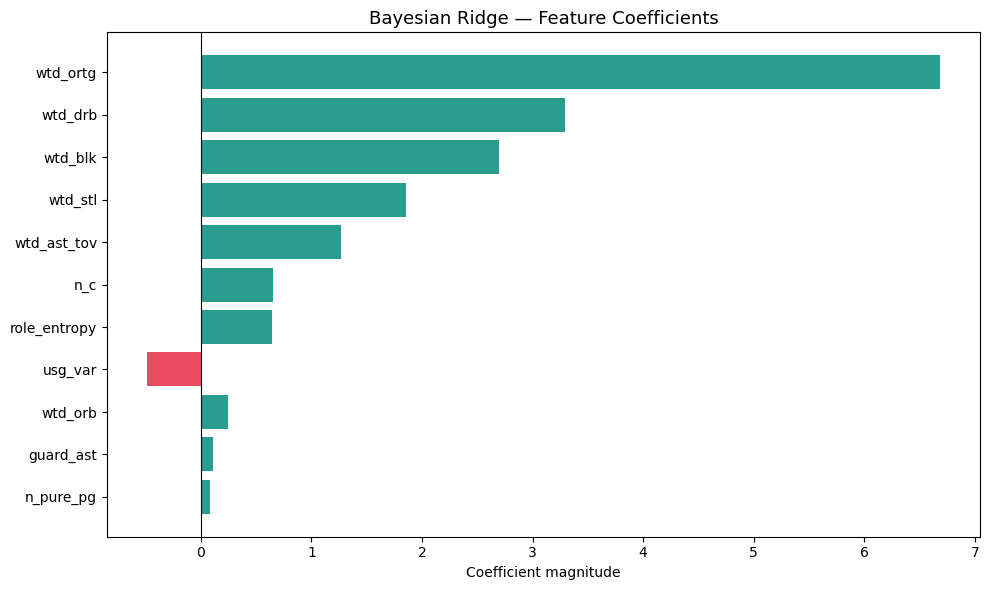

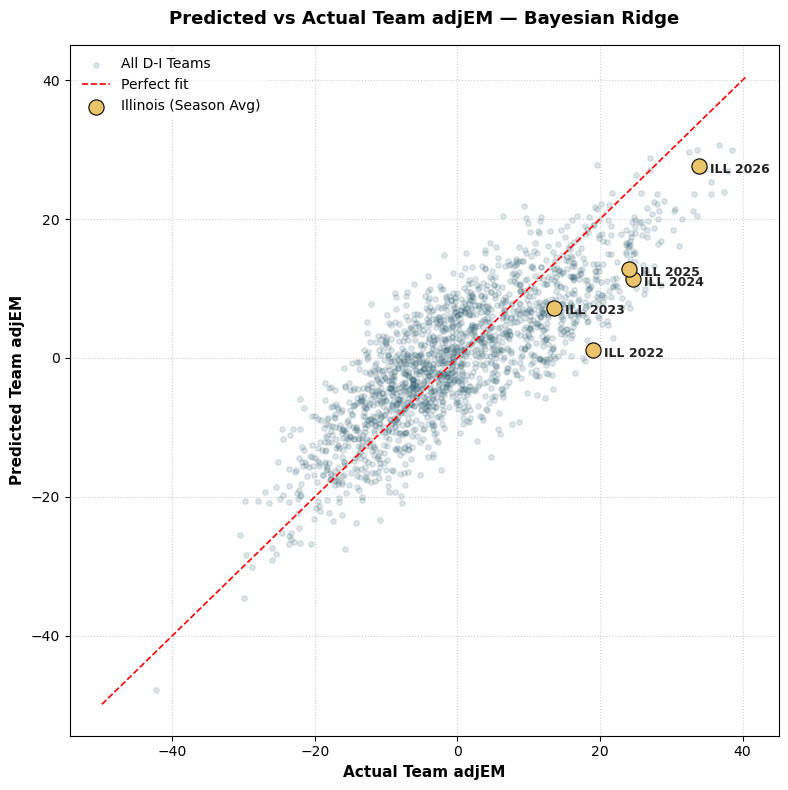

In [19]:
coefs = plot_feature_importance(best_pipeline, selected_cols)
plot_predicted_vs_actual(best_pipeline, df, feat_cols)

In [11]:
def build_lineup_features(lineup_players: pd.DataFrame) -> dict:
    """
    Given a DataFrame of 5 players (subset of the Illinois roster),
    compute the same features used in training.

    lineup_players must have the same columns as the filtered player data.
    Minutes are re-weighted to sum to 100% within the lineup.
    """
    grp = lineup_players.copy()

    grp = grp.rename(columns={" bpm": "bpm", " obpm": "obpm", " dbpm": "dbpm"})

    if grp["Min_per"].sum() == 0:
        grp["Min_per"] = 1.0  # equal weighting fallback
    w = grp["Min_per"] / grp["Min_per"].sum()

    wtd_obpm  = (grp["obpm"]    * w).sum()
    wtd_dbpm  = (grp["dbpm"]    * w).sum()
    wtd_ortg  = (grp["ORtg"]    * w).sum()
    wtd_efg   = (grp["eFG"]     * w).sum()
    wtd_ts    = (grp["TS_per"]  * w).sum()
    wtd_usg   = (grp["usg"]     * w).sum()
    wtd_ast   = (grp["AST_per"] * w).sum()
    wtd_tov   = (grp["TO_per"]  * w).sum()
    wtd_orb   = (grp["ORB_per"] * w).sum()
    wtd_drb   = (grp["DRB_per"] * w).sum()
    wtd_blk   = (grp["blk_per"] * w).sum()
    wtd_stl   = (grp["stl_per"] * w).sum()
    wtd_ast_tov = wtd_ast/(wtd_tov + 1e-9)

    fc = grp[grp["role"].isin(FRONTCOURT_ROLES)]
    guards = grp[grp["role"].isin(GUARD_ROLES)]
    fc_3p_rate = fc["TP_per"].mean() if len(fc) > 0 else 0.0
    guard_ast  = (guards["AST_per"] * (guards["Min_per"] / max(guards["Min_per"].sum(), 1))).sum() \
                 if len(guards) > 0 else 0.0
    
    usg_var    = grp["usg"].var()
    role_counts = grp["role"].value_counts()
    roles_present = set(grp["role"].unique())
    role_probs = grp["role"].value_counts(normalize=True)
    role_entropy = -(role_probs * np.log(role_probs + 1e-9)).sum()

    pair_feats = {}
    for r1, r2 in SYNERGY_PAIRS:
        key = f"pair_{r1.replace(' ','_')}_{r2.replace(' ','_')}"
        pair_feats[key] = int(r1 in roles_present and r2 in roles_present)

    return {
        "wtd_obpm": wtd_obpm, "wtd_dbpm": wtd_dbpm,
        "wtd_ortg": wtd_ortg, "wtd_efg": wtd_efg, "wtd_ts": wtd_ts,
        "wtd_usg": wtd_usg, "wtd_ast": wtd_ast, "wtd_tov": wtd_tov,
        "wtd_orb": wtd_orb, "wtd_drb": wtd_drb,
        "wtd_blk": wtd_blk, "wtd_stl": wtd_stl,
        "usg_var": usg_var, "fc_3p_rate": fc_3p_rate,
        "guard_ast": guard_ast,
        "role_entropy": role_entropy,
        "n_pure_pg":  role_counts.get("Pure PG",   0),
        "n_stretch4": role_counts.get("Stretch 4", 0),
        "n_pfc":      role_counts.get("PF/C",      0),
        "n_c":        role_counts.get("C",         0),
        "wtd_ast_tov":wtd_ast_tov,
        **pair_feats,
    }


def predict_lineup(pipeline, feat_cols: list, lineup_players: pd.DataFrame):
    """
    Predict adjEM for a 5-man lineup.
    Returns (point_estimate, std_estimate) — std from Bayesian posterior.
    """
    feats = build_lineup_features(lineup_players)
    X = np.array([[feats.get(c, 0.0) for c in feat_cols]])

    scaler = pipeline.named_steps["scaler"]
    selector = pipeline.named_steps["feature_selection"]
    model  = pipeline.named_steps["model"]
    X_scaled = scaler.transform(X)
    X_selected = selector.transform(X_scaled)
    mean, std = model.predict(X_selected, return_std=True)
    return float(mean[0]), float(std[0])


In [12]:
def rank_all_lineups(pipeline, feat_cols: list, roster: pd.DataFrame,
                     n: int = 5) -> pd.DataFrame:
    """
    Enumerate all C(roster_size, n) lineups and rank by predicted adjEM.
    Returns a DataFrame sorted by predicted adjEM descending.
    """
    results = []
    for combo in combinations(range(len(roster)), n):
        lineup = roster.iloc[list(combo)]
        mean, std = predict_lineup(pipeline, feat_cols, lineup)
        # 95% credible interval
        lower = mean - 1.96 * std
        upper = mean + 1.96 * std
        results.append({
            "players": " | ".join(lineup["player_name"].values),
            "roles":   " | ".join(lineup["role"].values),
            "pred_adjEM":  round(mean, 2),
            "ci_lower":    round(lower, 2),
            "ci_upper":    round(upper, 2),
            "uncertainty": round(std, 2),
        })

    return pd.DataFrame(results).sort_values("pred_adjEM", ascending=False).reset_index(drop=True)


In [13]:
joblib.dump({"pipeline": best_pipeline, "feat_cols": feat_cols}, MODEL_PATH)
print(f"\nModel saved → {MODEL_PATH}")


Model saved → ../models/lineup_model.pkl


In [14]:
print("Illinois 2026 Roster")
il_roster = players[
    (players["team"] == "Illinois") &
    (players["year"] == 2026) &
    (players["Min_per"] >= MIN_PCT_THRESHOLD)
].reset_index(drop=True)
print(il_roster[["player_name", "role", "Min_per"]].to_string(index=False))

print("Top 10 Projected Lineups")
rankings = rank_all_lineups(best_pipeline, feat_cols, il_roster)
print(rankings.head(10).to_string(index=False))



Illinois 2026 Roster
      player_name      role  Min_per
    Kylan Boswell   Combo G     60.1
       Jake Davis    Wing G     48.3
  Zvonimir Ivisic      PF/C     42.4
   Ben Humrichous Stretch 4     55.5
Andrej Stojakovic    Wing F     59.7
  Tomislav Ivisic      PF/C     57.5
    Keaton Wagler   Combo G     83.7
   David Mirkovic Stretch 4     72.7
Top 10 Projected Lineups
                                                                                players                                           roles  pred_adjEM  ci_lower  ci_upper  uncertainty
       Jake Davis | Zvonimir Ivisic | Ben Humrichous | Tomislav Ivisic | David Mirkovic    Wing G | PF/C | Stretch 4 | PF/C | Stretch 4       40.98     26.88     55.07         7.19
Zvonimir Ivisic | Ben Humrichous | Andrej Stojakovic | Tomislav Ivisic | David Mirkovic    PF/C | Stretch 4 | Wing F | PF/C | Stretch 4       40.35     26.22     54.48         7.21
    Zvonimir Ivisic | Ben Humrichous | Tomislav Ivisic | Keaton Wagler | David

In [15]:
lineups = [['Kylan Boswell','Jake Davis','Tomislav Ivisic','David Mirkovic','Keaton Wagler'],
           ['Kylan Boswell','Tomislav Ivisic','David Mirkovic','Andrej Stojakovic','Keaton Wagler'],
           ['Jake Davis','Tomislav Ivisic','David Mirkovic','Andrej Stojakovic','Keaton Wagler'],
           ['Kylan Boswell','Zvonimir Ivisic','David Mirkovic','Andrej Stojakovic','Keaton Wagler'],
           ['Kylan Boswell','Jake Davis','Zvonimir Ivisic','David Mirkovic','Keaton Wagler'],
           ['Kylan Boswell','Ben Humrichous','Tomislav Ivisic','Andrej Stojakovic','Keaton Wagler'],
           ['Jake Davis','Ben Humrichous','Tomislav Ivisic','David Mirkovic','Keaton Wagler']]

for lineup in lineups:
    players = il_roster[il_roster['player_name'].isin(lineup)]
    mean, std = predict_lineup(best_pipeline,feat_cols,players)
    print(f"Lineup: {lineup} with Mean: {mean} and std dev {std}")


Lineup: ['Kylan Boswell', 'Jake Davis', 'Tomislav Ivisic', 'David Mirkovic', 'Keaton Wagler'] with Mean: 18.252071826293783 and std dev 7.092185423619378
Lineup: ['Kylan Boswell', 'Tomislav Ivisic', 'David Mirkovic', 'Andrej Stojakovic', 'Keaton Wagler'] with Mean: 19.22631856347438 and std dev 7.070139381743173
Lineup: ['Jake Davis', 'Tomislav Ivisic', 'David Mirkovic', 'Andrej Stojakovic', 'Keaton Wagler'] with Mean: 20.929264169994045 and std dev 7.065135585224074
Lineup: ['Kylan Boswell', 'Zvonimir Ivisic', 'David Mirkovic', 'Andrej Stojakovic', 'Keaton Wagler'] with Mean: 29.27378337127223 and std dev 7.06490356262559
Lineup: ['Kylan Boswell', 'Jake Davis', 'Zvonimir Ivisic', 'David Mirkovic', 'Keaton Wagler'] with Mean: 28.972371118881274 and std dev 7.082936501496282
Lineup: ['Kylan Boswell', 'Ben Humrichous', 'Tomislav Ivisic', 'Andrej Stojakovic', 'Keaton Wagler'] with Mean: 15.444015759786504 and std dev 7.068790706036996
Lineup: ['Jake Davis', 'Ben Humrichous', 'Tomislav Ivi

In [16]:
il_roster.to_csv("../data/illinois_roster.csv", index=False)

metadata = {
    "feat_cols":     feat_cols,
    "selected_cols": selected_cols,
    "cv_results":    {k: float(v) for k, v in cv.items()},
    "season":        2026,
    "team":          "Illinois",
}
with open("../models/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Artifacts saved — ready for Streamlit app")

Artifacts saved — ready for Streamlit app


In [17]:
il_roster[["player_name", "role", "Min_per",'usg','blk_per','DRB_per']]

,player_name,role,Min_per,usg,blk_per,DRB_per
0,Kylan Boswell,Combo G,60.1,20.6,0.0,9.3
1,Jake Davis,Wing G,48.3,10.9,1.3,6.5
2,Zvonimir Ivisic,PF/C,42.4,16.2,12.9,21.6
3,Ben Humrichous,Stretch 4,55.5,11.5,3.3,13.4
4,Andrej Stojakovic,Wing F,59.7,23.8,1.9,13.1
5,Tomislav Ivisic,PF/C,57.5,19.9,2.6,16.7
6,Keaton Wagler,Combo G,83.7,25.7,1.3,10.0
7,David Mirkovic,Stretch 4,72.7,23.3,1.5,20.2
